<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Chest_X_Ray_Style_Image_Classification_Normal_vs_Pneumonia_like_Pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Import Libraries**

These libraries help us load images, build the CNN, train the model, and visualize results.

In [ ]:
# Import TensorFlow for deep learning
import tensorflow as tf

# Import Keras tools from TensorFlow
from tensorflow import keras

# Import neural network layers
from tensorflow.keras import layers

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for visualizing images and graphs
import matplotlib.pyplot as plt

**Step 2: Upload Dataset**

This allows you to upload the ZIP file named:

In [ ]:
# Import file upload tool from Google Colab
from google.colab import files

# Upload zipped dataset
uploaded = files.upload()

Saving synthetic_chest_xray_dataset.zip to synthetic_chest_xray_dataset.zip


**Step 3: Unzip Dataset**

This extracts the dataset folder so TensorFlow can read the images.

In [ ]:
import zipfile

zip_file_name = "synthetic_chest_xray_dataset.zip"

with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
    zip_ref.extractall()

**Step 4: Define Dataset Paths**

These paths tell Python where the training and testing images are stored.

In [ ]:
train_dir = "synthetic_chest_xray_dataset/train"
test_dir = "synthetic_chest_xray_dataset/test"

**Step 5: Load Images**

This automatically reads images from folders and creates labels based on folder names.

In [ ]:
image_size = (128, 128)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size
)

Found 320 files belonging to 2 classes.
Found 80 files belonging to 2 classes.


**Step 6: Check Class Names**

This shows the two classes:
*  normal
*  pneumonia_like


In [ ]:
class_names = train_data.class_names

print(class_names)

['normal', 'pneumonia_like']


**Step 7: Visualize Sample Images**

This helps students see the images before training the CNN.

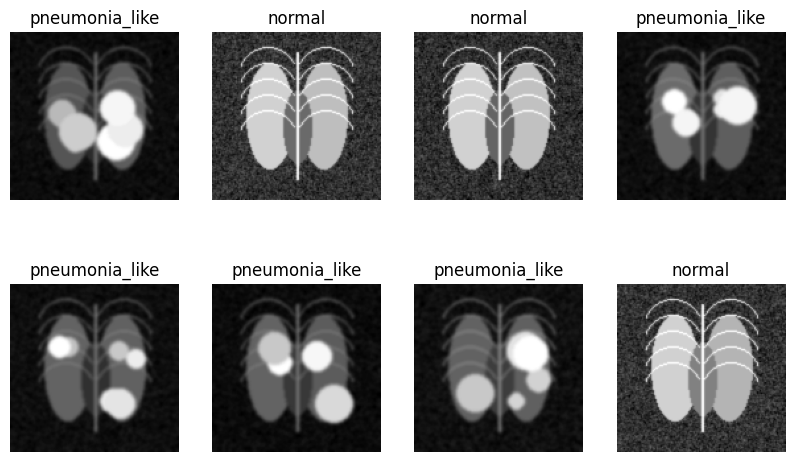

In [ ]:
plt.figure(figsize=(10, 6))

for images, labels in train_data.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

**Step 8: Build CNN Model**
*  **Rescaling** normalizes pixel values.
*  **Conv2D** learns image patterns.
*  **MaxPooling2D** reduces image size.
*   **Flatten** converts image features into one vector.
*   **Dense** makes the final decision.
*  **Dropout** reduces overfitting.

*  **Sigmoid** is used because this is binary classification.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

**Step 9: Compile Model**
*  **adam** updates model weights.
*  **binary_crossentropy** is used for two classes.
*   **accuracy** measures correct predictions.

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Step 10: Show Model Summary**

This shows all CNN layers and trainable parameters.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Step 11: Train Model**

The CNN learns visual patterns from the training images and checks performance on the test images.

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - accuracy: 0.8844 - loss: 0.2093 - val_accuracy: 1.0000 - val_loss: 1.3205e-06
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 6.2059e-07
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 1.7901e-04 - val_accuracy: 1.0000 - val_loss: 1.0319e-07
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 5.4545e-04 - val_accuracy: 1.0000 - val_loss: 1.0496e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 1.4366e-04 - val_accuracy: 1.0000 - val_loss: 5.4810e-05
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 2.0236e-04 - val_accuracy: 1.0000 - val_loss: 1.7335e-05
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 2.9096e-05 - val_accuracy: 1.0000 - val_loss: 2.1718e-06
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy:

**Step 12: Plot Accuracy**

This shows whether the model improves during training.

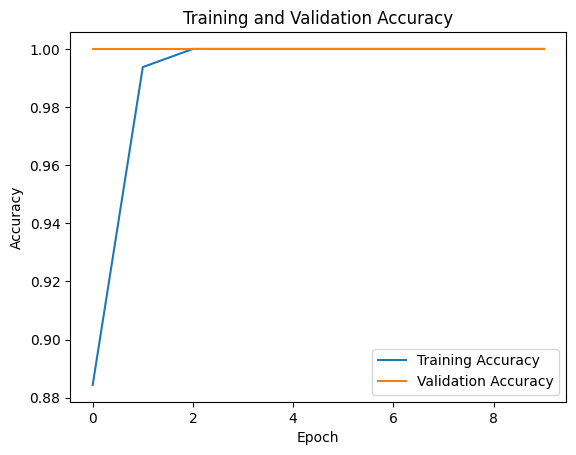

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Step 13: Plot Loss**

Loss shows model error. A good model usually has decreasing loss.

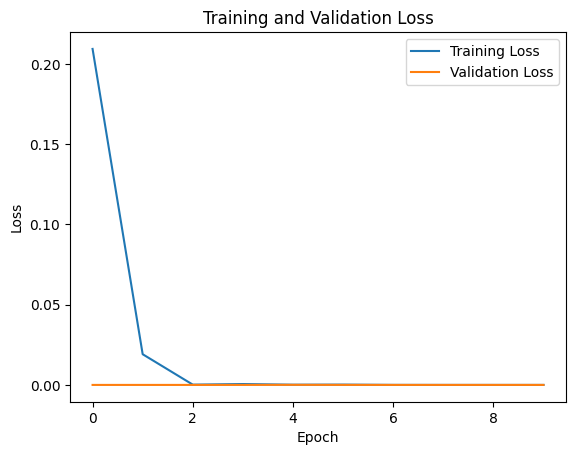

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Step 14: Evaluate Model**

This measures performance on unseen test images.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 1.1260e-08
Test Loss: 1.1260167021021061e-08
Test Accuracy: 1.0


**Step 15: Make Predictions**

The model outputs probabilities. Values above 0.5 become class 1, and values below or equal to 0.5 become class 0.

In [ ]:
for images, labels in test_data.take(1):
    predictions = model.predict(images)
    predicted_labels = (predictions > 0.5).astype(int).flatten()
    actual_labels = labels.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step


**Step 16: Visualize Predictions**

This is very powerful for teaching because students can visually compare predictions with actual labels.

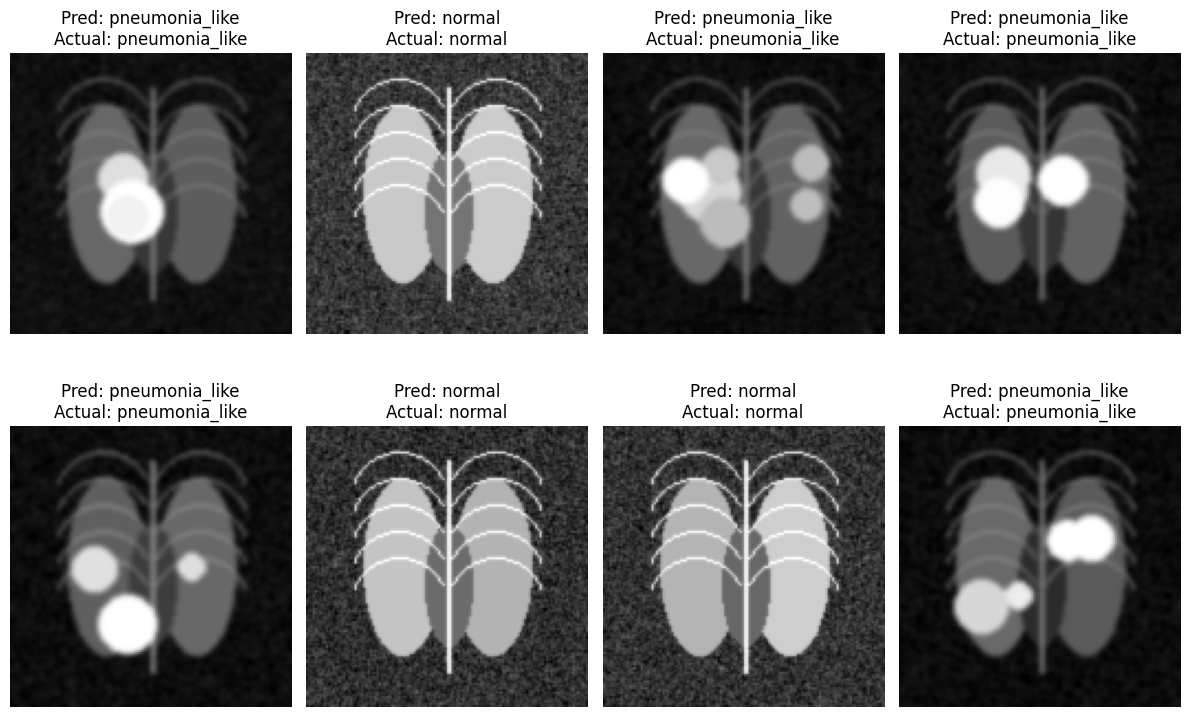

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_name = class_names[predicted_labels[i]]
    actual_name = class_names[actual_labels[i]]

    plt.title(f"Pred: {predicted_name}\nActual: {actual_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 17: Save Model**

This saves the trained CNN model for future use.

In [ ]:
model.save("healthcare_cnn_model.keras")

In [ ]:
from google.colab import files

files.download("healthcare_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>